In [571]:
import pyreadstat as rs
import os
import DE_Utilities as DE
import numpy as np
import copy as c
import sklearn.datasets as datasets

In [14]:
# DE.xpt_to_csv("datasets" , "datasets_csv")

In [15]:
# DE.join_datasets("datasets_csv" , output_dir = "silver" , first_file="ACQ_L.csv" , join_on='SEQN')

In [16]:
import pandas as pd 

In [17]:
df = pd.read_csv("datasets_csv/HIQ_L.csv")

In [18]:
df_2 = pd.read_csv("datasets_csv/HSQ_L.csv")

In [19]:
df.columns

Index(['Unnamed: 0', 'SEQN', 'HIQ011', 'HIQ032A', 'HIQ032B', 'HIQ032C',
       'HIQ032D', 'HIQ032E', 'HIQ032F', 'HIQ032H', 'HIQ032I', 'HIQ210'],
      dtype='str')

In [20]:
df.merge(df_2 , on = "SEQN" , how = "outer")

,Unnamed: 0_x,SEQN,HIQ011,HIQ032A,HIQ032B,HIQ032C,HIQ032D,HIQ032E,HIQ032F,HIQ032H,HIQ032I,HIQ210,Unnamed: 0_y,HSQ590
0,0,130378.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,NaN
1,1,130379.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0
2,2,130380.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,1.0,2.0,1.0
3,3,130381.0,1.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,4,130382.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11928,11928,142306.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11929,11929,142307.0,1.0,NaN,2.0,NaN,4.0,NaN,NaN,NaN,NaN,2.0,6611.0,1.0
11930,11930,142308.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,6612.0,2.0
11931,11931,142309.0,1.0,1.0,NaN,NaN,NaN,NaN,6.0,NaN,NaN,2.0,6613.0,1.0


In [21]:
df = pd.read_csv("bronze/final_data.csv")

In [22]:
df = df.select_dtypes(exclude="str")

In [23]:
m , n = df.shape

In [24]:
m

11933

In [25]:
fil = (df > 0).astype("int").sum(axis = 0) > 0.80 * m

In [26]:
cols = df.loc[: , fil].columns

In [27]:
required_cols = ['BPQ020' , 'RIAGENDR' , "RIDAGEYR"  , "BMXBMI", "PAD790Q" , "DIQ010" , "DR1TSODI" ] 
required_cols_mapping = ["had_hypertension" , "gender" , "age_at_years"   , "Body_Mass_Index"   , "Frequency_of_moderate_LTPA" , "had_diabetes"  , "Sodium_(mg)_perday"]

In [28]:
df_f_v_1 = df.loc[: , required_cols]

In [29]:
df_f_v_1.columns = required_cols_mapping

In [30]:
df_f_v_2 = df_f_v_1[~df_f_v_1.had_hypertension.isna()]

In [31]:
df_f_v_3 = df_f_v_2

In [32]:
BMI_mean = df_f_v_3.Body_Mass_Index.mean()

In [33]:
df_f_v_4 = df_f_v_3.fillna(BMI_mean)

In [34]:
df_f_v_5 = df_f_v_4[(df_f_v_4.had_hypertension == 1.0) | (df_f_v_4.had_hypertension == 2.0)]


In [35]:
df_f_v_5.had_hypertension = df_f_v_5.had_hypertension.apply(lambda row : 1 if row == 1.0 else 0)
df_f_v_5.gender = df_f_v_5.gender.apply(lambda row : 1 if row == 1.0 else 0)

In [36]:
df_f_v_6 = df_f_v_5.loc[(df_f_v_5.had_diabetes == 1.0)|(df_f_v_5.had_diabetes == 2.0)]

In [37]:
df_f_v_6.had_diabetes = df_f_v_6.had_diabetes.apply(lambda row : 1 if row == 1.0 else 0)

In [38]:
df_f_v_7 = df_f_v_6.rename(columns = {"had_hypertension" : "target"})

In [39]:
df_f_v_7

,target,gender,age_at_years,Body_Mass_Index,Frequency_of_moderate_LTPA,had_diabetes,Sodium_(mg)_perday
0,1,1,43.0,27.000000,3.0,0,2628.000000
1,1,1,66.0,33.500000,4.0,0,5635.000000
2,0,0,44.0,29.700000,1.0,1,2890.000000
6,0,1,43.0,29.465971,0.0,0,29.465971
7,0,0,65.0,29.465971,1.0,0,29.465971
...,...,...,...,...,...,...,...
11925,0,0,69.0,27.900000,2.0,1,342.000000
11929,0,0,49.0,29.465971,3.0,1,3014.000000
11930,0,1,50.0,26.400000,1.0,0,29.465971
11931,0,1,40.0,25.500000,2.0,0,9476.000000


In [40]:
min_target = df_f_v_7.groupby('target').count().gender.min()

class_1 = df_f_v_7.loc[df_f_v_7.target == 1].iloc[:min_target]
class_0 = df_f_v_7.loc[df_f_v_7.target == 0].iloc[:min_target]

df_f_v_final = pd.concat([class_1 , class_0]).astype("float")

In [41]:
cols = df_f_v_final.columns[1:]
for col in cols:
    mean_value = df_f_v_final.loc[: , col].mean()
    max_value = df_f_v_final.loc[: , col].max()
    min_value = df_f_v_final.loc[: , col].min()
    
    result = (df_f_v_final.loc[: , col] - np.array(mean_value))/(np.array(max_value) - np.array(min_value))
    df_f_v_final.loc[: , col] = result

In [42]:
df_f_v_final

,target,gender,age_at_years,Body_Mass_Index,Frequency_of_moderate_LTPA,had_diabetes,Sodium_(mg)_perday
0,1.0,0.536033,-0.159269,-0.047196,-0.004775,-0.166786,0.050168
1,1.0,0.536033,0.200106,0.061864,-0.004675,-0.166786,0.256085
9,1.0,-0.463967,0.231356,0.214549,-0.005075,-0.166786,0.301212
10,1.0,-0.463967,-0.409269,0.233005,-0.004575,-0.166786,-0.127777
11,1.0,0.536033,0.090731,-0.030418,-0.004775,-0.166786,0.108581
...,...,...,...,...,...,...,...
6239,0.0,0.536033,-0.581144,-0.146190,-0.002128,-0.166786,-0.009340
6244,0.0,-0.463967,0.090731,-0.005821,-0.004775,-0.166786,-0.127777
6245,0.0,0.536033,0.012606,-0.055586,-0.004975,-0.166786,0.014764
6247,0.0,-0.463967,-0.393644,0.134012,-0.004575,-0.166786,0.242800


In [43]:
X = df_f_v_final.iloc[: , 1:]
Y = df_f_v_final.iloc[: , 0]

In [44]:
def transform(df):
    required_cols = ['BPQ020' , 'RIAGENDR' , "RIDAGEYR"  , "BMXBMI", "PAD790Q" , "DIQ010" , "DR1TSODI" ] 
    required_cols_mapping = ["had_hypertension" , "gender" , "age_at_years"   , "Body_Mass_Index"   , "Frequency_of_moderate_LTPA" , "had_diabetes"  , "Sodium_(mg)_perday"]
    df_f_v_1 = df.loc[: , required_cols]
    df_f_v_1.columns = required_cols_mapping
    df_f_v_2 = df_f_v_1[~df_f_v_1.had_hypertension.isna()]
    df_f_v_3 = df_f_v_2
    BMI_mean = df_f_v_3.Body_Mass_Index.mean()
    df_f_v_4 = df_f_v_3.fillna(BMI_mean)
    df_f_v_5 = df_f_v_4[(df_f_v_4.had_hypertension == 1.0) | (df_f_v_4.had_hypertension == 2.0)]
    df_f_v_5.had_hypertension = df_f_v_5.had_hypertension.apply(lambda row : 1 if row == 1.0 else 0)
    df_f_v_5.gender = df_f_v_5.gender.apply(lambda row : 1 if row == 1.0 else 0)
    df_f_v_6 = df_f_v_5.loc[(df_f_v_5.had_diabetes == 1.0)|(df_f_v_5.had_diabetes == 2.0)]
    df_f_v_6.had_diabetes = df_f_v_6.had_diabetes.apply(lambda row : 1 if row == 1.0 else 0)
    df_f_v_final = df_f_v_6.rename(columns = {"had_hypertension" : "target"})
    X = df_f_v_final.iloc[: , 1:]
    Y = df_f_v_final.iloc[: , 0]

    return df_f_v_final , X , Y
    


In [45]:
def load(destinations , data):
    
    if len(destinations) != len(data):
        logger.error("The length of destinations is not equal to length of data")
        return None
    logger.info(f"The data is being loaded to destinations")
    try:
        i = 0 
        while i < len(destinations):
            df = data[i]
            dest = destinations[i]
            df.to_csv(dest)
            i +=1
        logger.info(f"The data has been loaded to destinations successfully")
    except Exception as e:
        logger.error(f"The data hasn't been loaded successfully , Error : {e}")
    return None

    

In [46]:
class Logistic_regression_model:
    def __init__(self , X , Y , learning_rate = .1 , EPOCHS = 3000):
        self.X = X
        self.Y = Y
        self.learning_rate = learning_rate
        self.EPOCHS = EPOCHS
        self.W = None
        self.b = None
        self.costs = []
    
    def sigmoid(self , Z):
        g = 1 /(1 + np.exp(-1 * Z))
        return g

    def initialize(self):
        m , n = self.X.shape
        W = np.random.randn(1 , n)
        b = 0
        return W , b
           
    def compute_linear(self , W , b , X):
        Z = np.dot(W , X.T) + b
        g = self.sigmoid(Z)

        return g
    
    def cost(self , g):
        m , n = self.X.shape
        Y = self.Y.T
        loss = Y * np.log(g) + (1 - Y) * np.log(1 - g)

        cost_v = float((-1/m) * np.sum(loss))

        return cost_v
    
    def derivatives(self , g):
        m , n = self.X.shape

        dW = (1/m) * np.dot(g - self.Y.T , self.X)
        db = (1/m) * np.sum(g - self.Y.T)

        return dW , db
    

    def update(self , dW, db):
        
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db
    def fit(self):
        self.W , self.b = self.initialize()

        for _ in range(self.EPOCHS):
            g = self.compute_linear(self.W , self.b , self.X)
            cost = self.cost(g)
            self.costs.append(cost)
            dW , db = self.derivatives(g)
            self.update(dW , db)
    
    def predict(self , X , threshold = 0.5):
        predictions = self.compute_linear(self.W , self.b , X)
        
        return (predictions > threshold).astype("int")[0]


In [47]:
import sklearn.model_selection as m
import sklearn.linear_model as linear
X_train , X_test , Y_train , Y_test = m.train_test_split(X.to_numpy() , Y.to_numpy() , test_size=0.2 , random_state=42 )

In [48]:
sklearn_model = linear.LogisticRegression(max_iter= 15000)
my_model = Logistic_regression_model(X_train , Y_train , 0.1 , 20000)

In [49]:
sklearn_model.fit(X_train , Y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
my_model.fit()

In [51]:
costs = my_model.costs

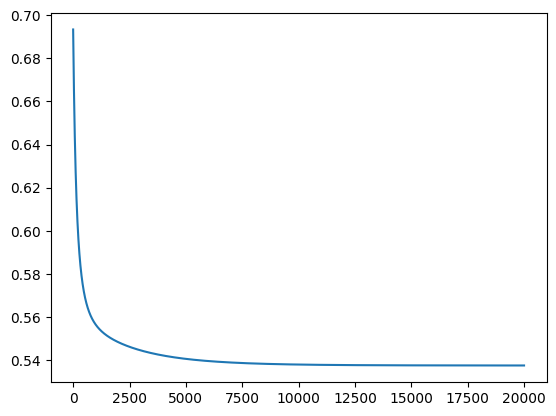

In [52]:
import matplotlib.pyplot as plt

plt.plot([i for i in range(len(costs))] , costs)

In [53]:
from sklearn.metrics import accuracy_score

yhat_sk_model = sklearn_model.predict(X_test)
yhat_my_model = my_model.predict(X_test)

In [54]:
sk_accuracy = accuracy_score(Y_test , yhat_sk_model) 
my_accuracy = accuracy_score(Y_test , yhat_my_model)

In [484]:
sk_accuracy , my_accuracy

(0.7522281639928698, 0.750445632798574)

In [55]:
yhat_sk_model

array([0., 1., 0., ..., 1., 0., 1.], shape=(1122,))

In [56]:
def complex_matrix(y_true , y_pred , num_classes = 2):
    matrix = np.zeros(shape = (num_classes , num_classes))
    y_true = list(y_true)
    y_pred = list(y_pred)
    for i in range(len(y_true)):
        actual = y_true[i]
        predicted = y_pred[i] 
        matrix[int(actual)][int(predicted)] += 1
    
    return matrix

In [57]:
complex_matrix(Y_test , yhat_sk_model)

array([[400., 143.],
       [135., 444.]])

In [58]:
import seaborn 

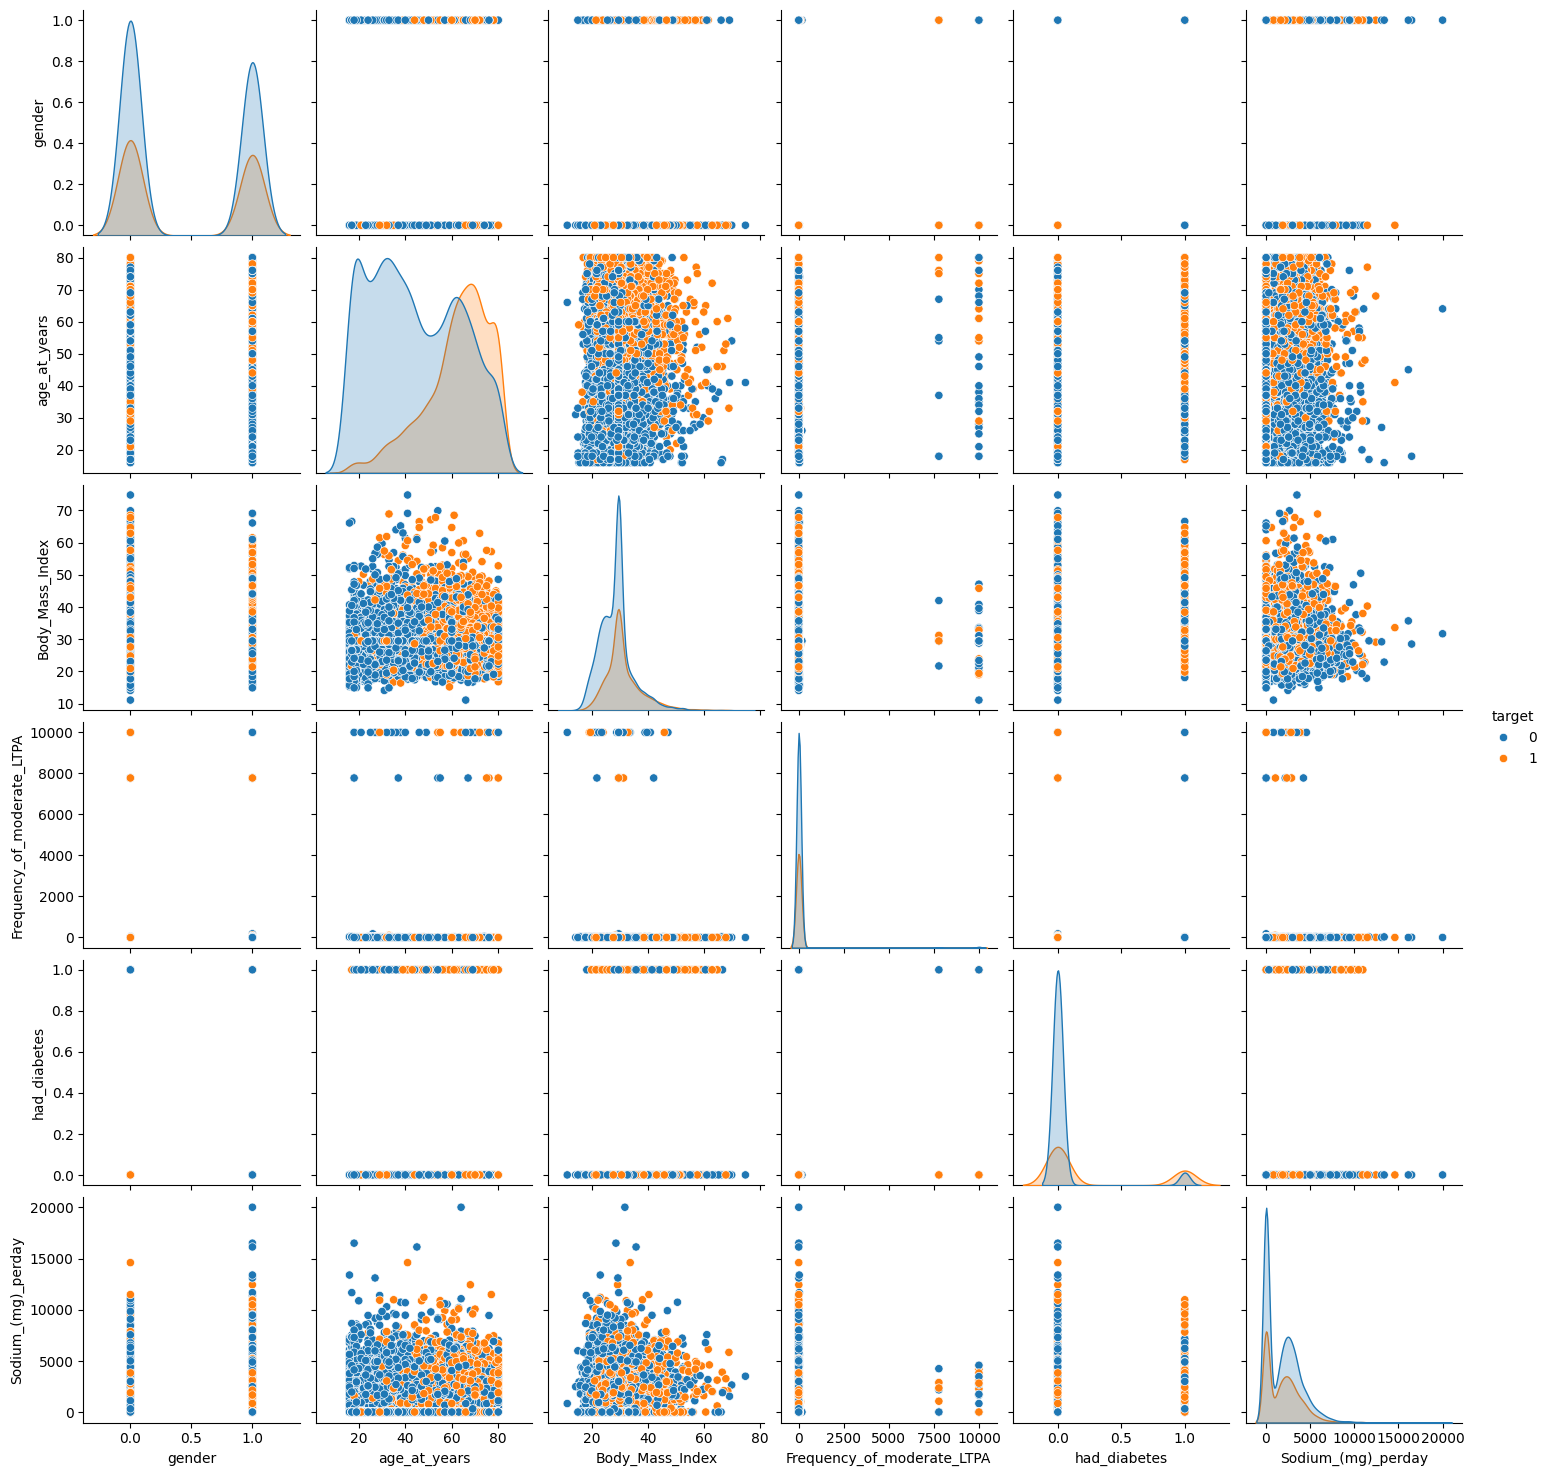

In [59]:
seaborn.pairplot(df_f_v_7 , hue = "target")

In [ ]:
class NN_Model:
    def __init__(self , X , Y , learning_rate = .1 , EPOCHS = 3000 , layers_dims = [1]):

        self.X = X
        if type(Y) != np.ndarray:
            self.Y = Y.to_numpy()
        else:
            self.Y = Y
        self.Y = self.Y.reshape((self.Y.shape[0] , 1))
        self.learning_rate = learning_rate
        self.EPOCHS = EPOCHS
        self.layers = [self.X.shape[1]] + layers_dims + [1]
        self.parameters = None
    
    def _sigmoid(self , Z):
        A = 1 / (1 + np.exp(-1 * Z))

        cache = {"A" : A , "Z": Z}

        return cache
    
    def _derivative_sigmoid(self , Z):
        cache = self._sigmoid(Z)
        A = cache['A']
        derivative = A * (1 - A)

        return derivative
    
    def _relu(self , Z):
        zeros = np.zeros(shape = Z.shape)
        A = np.maximum(zeros , Z)
        cache = {"A" : A , "Z" : Z}
        
        return cache
    

    def _derivatvie_relu(self , Z):
        
        derivative = (Z > 0).astype('int')
        
        return derivative

    def _linear(self , W , b , A):


        Z = np.dot(W , A) + b
        cache = {'Z' : Z , 'W' : W , "b" : b}
        return cache
    
    def initialize_parameters(self):
        L = len(self.layers)
        all_W = []
        all_b = []
        for l in range(1 , L):
            W = np.random.randn(self.layers[l] , self.layers[l - 1]) * np.sqrt(2/self.layers[l - 1])
            b = np.zeros(shape = (self.layers[l] , 1))
            all_W.append(W)
            all_b.append(b)

        parameters = {'all_W' : all_W, 'all_b': all_b}

        self.parameters = parameters
        return parameters
    

    def forward_propagation(self , parameters , X = None):

        all_A = []
        all_Z = []
        all_W = parameters['all_W']
        all_b = parameters['all_b']
        A = X.T
        L = len(self.layers)
        

        for l in range(L - 2):
                A_prev = A
                w = all_W[l]
                b = all_b[l]
                cache_1 = self._linear(w , b , A_prev)
                Z = cache_1['Z']
                cache_2 = self._relu(Z)
                A = cache_2['A']
                all_A.append(A)
                all_Z.append(Z)

        
        w = all_W[L - 2]
        b = all_b[L - 2]
        cache_1 = self._linear(w , b , A)
        Z = cache_1['Z']
        all_Z.append(Z)
        cache_2 = self._sigmoid(Z)
        AL = cache_2['A']
        all_A.append(AL)
        cache = {'AL' :AL , 'all_W' :all_W , "all_b" : all_b , 'all_A' : all_A , 'all_Z' :all_Z}

        return cache

    def cost(self , AL):
        m , n = self.X.shape
        Y = self.Y.T

        loss = Y * np.log(AL) + (1 - Y) * np.log(1 - AL)

        cost = (-1/m) * np.sum(loss)

        return cost
    

    def linear_backprop(self , dA , Z , activation):
        

        if activation == 'sigmoid':
            dZ = dA * self._derivative_sigmoid(Z)

        if activation == 'relu':
            dZ = dA * self._derivatvie_relu(Z)
        
        cache = {'dZ' : dZ , 'dA' : dA , 'Z' : Z}

        return cache
    
    def derivative_backprop(self , dZ , A_prev , W):
        m , n = self.X.shape

        dW = (1/m) * np.dot(dZ , A_prev.T)
        db = (1/m) * np.sum(dZ , axis = 1 , keepdims = True)
        dA_prev = np.dot(W.T , dZ)

        cache = {'dW' : dW , 'db' : db , 'dA_prev' : dA_prev}

        return cache 
    
    def _calculate_dAL(self , AL):
        Y = self.Y.T
        dAL = (-Y/AL) + ((1 - Y)/(1 - AL))

        return dAL

    def back_propagation(self , parameters):
        
        AL = parameters['AL']
        all_W = parameters['all_W']
        L = len(all_W)
        all_A = [self.X.T] + parameters['all_A']
        all_Z = parameters['all_Z']
        all_dW = [0] * len(all_W)
        all_db = [0] * len(all_W) 

        dAL = self._calculate_dAL(AL)
        A_prev = all_A[-2]
        W = all_W[-1]
        Z = all_Z[-1]
        cache_1 = self.linear_backprop(dAL , Z , activation='sigmoid')
        dZ = cache_1['dZ']
        cache_2 = self.derivative_backprop(dZ , A_prev  , W)
        dW = cache_2['dW']
        db = cache_2['db']
        all_dW[-1] = dW
        all_db[-1] = db
        dA_prev = cache_2['dA_prev']

        
        for l in range(L - 2 , -1 , -1):
            
            A_prev = all_A[l]
            W = all_W[l]
            Z = all_Z[l]

            cache_1 = self.linear_backprop(dA_prev , Z , activation='relu')
            dZ = cache_1['dZ']

            cache_2 = self.derivative_backprop(dZ , A_prev  , W)
            dW = cache_2['dW']
            db = cache_2['db']

            all_dW[l] = dW
            all_db[l] = db
            dA_prev = cache_2['dA_prev']


        parameters = {'all_dW' : all_dW , 'all_db' : all_db , **parameters}
        return parameters 

    def update(self , parameters):
        all_dW = parameters['all_dW']
        all_db = parameters['all_db']
        all_W  = c.deepcopy(parameters['all_W'])
        all_b  = c.deepcopy(parameters['all_b'])

        for i in range(len(all_W)):
            all_W[i] -= self.learning_rate * all_dW[i]
            all_b[i] -= self.learning_rate * all_db[i]

        new_parameters = {"all_W"  : all_W , "all_b" : all_b}

        return new_parameters
    

    def fit(self):

        parameters = self.initialize_parameters()
        costs = []
        for _ in range(self.EPOCHS):

            cache = self.forward_propagation(parameters , X = self.X)
            AL = cache['AL']
            cost = self.cost(AL)
            costs.append(cost)
            parameters_backprop = self.back_propagation(cache)
            parameters = self.update(parameters=parameters_backprop)

        self.parameters = parameters

        return parameters , costs
    
    def predict(self , X , threshold = .5):

        result = self.forward_propagation(self.parameters , X)['AL']


        return (result > threshold).astype('int')[0]


In [586]:
data = datasets.load_breast_cancer()['data']
target = datasets.load_breast_cancer()['target']

In [587]:
model = NN_Model(data , target , layers_dims=[3 , 3 , 3] , EPOCHS= 20000)

In [588]:
model.layers

[30, 3, 3, 3, 1]

In [590]:
parameters , costs = model.fit()

/tmp/ipykernel_19717/1199474943.py:104: RuntimeWarning: divide by zero encountered in log
  loss = Y * np.log(AL) + (1 - Y) * np.log(1 - AL)
/tmp/ipykernel_19717/1199474943.py:104: RuntimeWarning: invalid value encountered in multiply
  loss = Y * np.log(AL) + (1 - Y) * np.log(1 - AL)
/tmp/ipykernel_19717/1199474943.py:137: RuntimeWarning: divide by zero encountered in divide
  dAL = (-Y/AL) + ((1 - Y)/(1 - AL))
/tmp/ipykernel_19717/1199474943.py:137: RuntimeWarning: invalid value encountered in divide
  dAL = (-Y/AL) + ((1 - Y)/(1 - AL))
/tmp/ipykernel_19717/1199474943.py:115: RuntimeWarning: invalid value encountered in multiply
  dZ = dA * self._derivative_sigmoid(Z)


In [591]:
parameters['all_W']

[array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan]]),
 array([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]]),
 array([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]]),
 array([[nan, nan, nan]])]

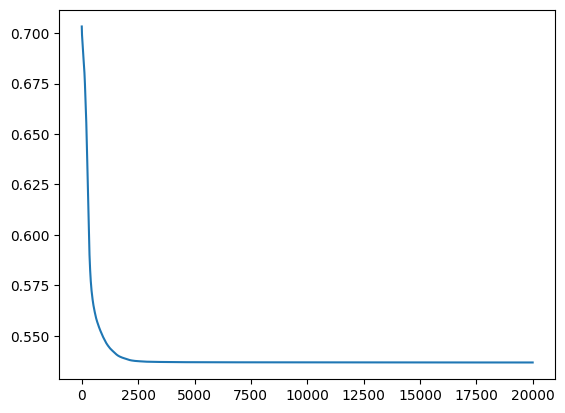

In [567]:
plt.plot([i for i in range(len(costs))] , costs)

In [568]:
y_pred = model.predict(X_test)

In [569]:
y_pred_2 = model.predict(X_train)

In [570]:
accuracy_score(Y_test , y_pred) , accuracy_score(Y_train , y_pred_2)

(0.7549019607843137, 0.7341659232827832)

In [554]:
sk_accuracy

0.7522281639928698

In [607]:
cm = complex_matrix(Y_test , yhat_sk_model)

In [614]:
cm

array([[400., 143.],
       [135., 444.]])

In [ ]:
import seaborn as sb
def save_heatmap(cm , filename , name = "complex matrix"):
    ax = sb.heatmap(cm , annot = True , fmt = '.0f')
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.name
    plt.show()
    ax.get_figure().savefig(f"graphs/{filename}.png")

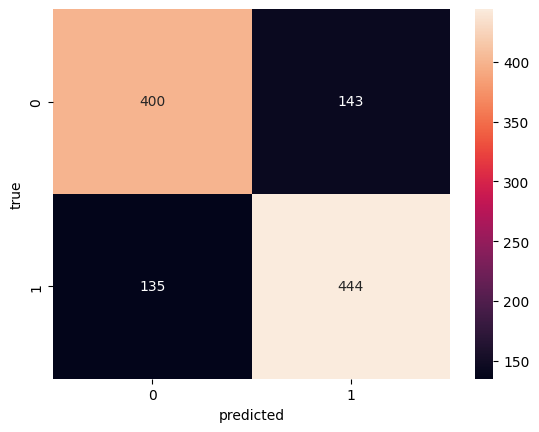

In [619]:
save_heatmap(cm)

In [576]:
test = sklearn_model.fit(data , target)

In [580]:
accuracy_score(target , test.predict(data))

0.9578207381370826

In [579]:
model = Logistic_regression_model(data , target)

In [583]:
model.fit()

/tmp/ipykernel_19717/3479572573.py:30: RuntimeWarning: divide by zero encountered in log
  loss = Y * np.log(g) + (1 - Y) * np.log(1 - g)
/tmp/ipykernel_19717/3479572573.py:30: RuntimeWarning: invalid value encountered in multiply
  loss = Y * np.log(g) + (1 - Y) * np.log(1 - g)
/tmp/ipykernel_19717/3479572573.py:12: RuntimeWarning: overflow encountered in exp
  g = 1 /(1 + np.exp(-1 * Z))


In [585]:
accuracy_score(target , model.predict(data))

/tmp/ipykernel_19717/3479572573.py:12: RuntimeWarning: overflow encountered in exp
  g = 1 /(1 + np.exp(-1 * Z))


0.9086115992970123

In [597]:
data = pd.DataFrame(data , columns=datasets.load_breast_cancer()['feature_names'])
data = data.astype("float")

In [598]:
cols = data.columns

for col in cols:
    data.loc[: , col] =  (data.loc[: , col] - data.loc[: , col].mean()) / (data.loc[: , col].max() - data.loc[: , col].min())

In [600]:
model = NN_Model(data , target)

In [602]:
parameters , costs = model.fit()

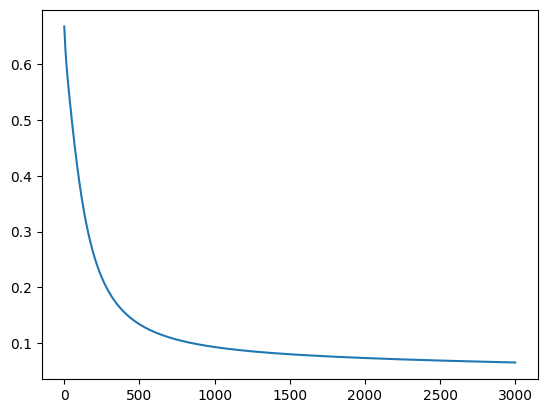

In [603]:
plt.plot([i for i in range(len(costs))] , costs)

In [604]:
accuracy_score(target , model.predict(data))

0.984182776801406

In [ ]:
complex_matrix(Y_test , )

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.182815,-0.301307,0.213053,0.146813,0.198968,0.531437,0.495081,0.487976,0.306758,0.335139,...,0.324113,-0.222474,0.385173,0.279792,0.196998,0.399079,0.351207,0.518192,0.335156,0.229268
1,0.304923,-0.051392,0.282848,0.284671,-0.104905,-0.078833,-0.004450,0.105621,0.000193,-0.129057,...,0.310239,-0.060427,0.256680,0.264308,-0.056585,-0.065649,-0.024432,0.245339,-0.029717,0.033282
2,0.263274,0.066295,0.262808,0.232497,0.119524,0.170416,0.254453,0.392549,0.129991,-0.059132,...,0.259723,-0.003924,0.225304,0.203602,0.079452,0.165163,0.142341,0.441216,0.140399,0.023837
3,-0.128132,0.036874,-0.099434,-0.114014,0.416536,0.550761,0.357546,0.279726,0.396657,0.729621,...,-0.048353,0.021929,-0.041791,-0.076898,0.511335,0.593799,0.331239,0.491044,0.736693,0.584115
4,0.291671,-0.167388,0.298051,0.272369,0.035567,0.087292,0.255859,0.275253,-0.001323,-0.083564,...,0.223081,-0.240065,0.223810,0.170669,0.033226,-0.047797,0.102086,0.164583,-0.105806,-0.047001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.351778,0.104848,0.345733,0.349570,0.132163,0.035455,0.363404,0.447221,-0.043242,-0.138324,...,0.326603,0.019264,0.293036,0.281758,0.056999,-0.041685,0.110632,0.367676,-0.165731,-0.083929
565,0.284098,0.303022,0.271101,0.257099,0.012997,-0.002886,0.129336,0.243493,-0.030110,-0.157279,...,0.263992,0.335095,0.237755,0.209009,-0.104131,-0.060216,0.039386,0.165614,-0.064805,-0.115281
566,0.117029,0.297273,0.112853,0.086198,-0.106620,-0.006260,0.008694,0.020382,-0.111929,-0.133058,...,0.096436,0.225021,0.096812,0.059825,-0.121961,0.053492,0.054402,0.093449,-0.134586,-0.037687
567,0.306342,0.339545,0.332603,0.258796,0.193552,0.529596,0.615278,0.512330,0.295647,0.155063,...,0.336920,0.366279,0.385173,0.231129,0.215488,0.595546,0.532357,0.516817,0.233835,0.262719
